In [5]:
# Check the versions of libraries
# Python version
import sys
print('Python: {}'.format(sys.version))
# scipy
import scipy
print('scipy: {}'.format(scipy.__version__))
numpy
import numpy
print('numpy: {}'.format(numpy.__version__))
# matplotlib
import matplotlib
print('matplotlib: {}'.format(matplotlib.__version__))
# pandas
import pandas
print('pandas: {}'.format(pandas.__version__))
# scikit-learn
import sklearn
print('sklearn: {}'.format(sklearn.__version__))

Python: 3.13.5 (tags/v3.13.5:6cb20a2, Jun 11 2025, 16:15:46) [MSC v.1943 64 bit (AMD64)]
scipy: 1.16.1
numpy: 2.3.2
matplotlib: 3.10.6
pandas: 2.3.2
sklearn: 1.7.1


In [6]:
# Load libraries
import pandas
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt
from sklearn import model_selection
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

In [7]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
names = ['sepal-length', 'sepal-width', 'petal-length', 'petal-width', 'class']
dataset = pandas.read_csv(url, names=names)

print(dataset.shape)

print(dataset.head(30))

(150, 5)
    sepal-length  sepal-width  petal-length  petal-width        class
0            5.1          3.5           1.4          0.2  Iris-setosa
1            4.9          3.0           1.4          0.2  Iris-setosa
2            4.7          3.2           1.3          0.2  Iris-setosa
3            4.6          3.1           1.5          0.2  Iris-setosa
4            5.0          3.6           1.4          0.2  Iris-setosa
5            5.4          3.9           1.7          0.4  Iris-setosa
6            4.6          3.4           1.4          0.3  Iris-setosa
7            5.0          3.4           1.5          0.2  Iris-setosa
8            4.4          2.9           1.4          0.2  Iris-setosa
9            4.9          3.1           1.5          0.1  Iris-setosa
10           5.4          3.7           1.5          0.2  Iris-setosa
11           4.8          3.4           1.6          0.2  Iris-setosa
12           4.8          3.0           1.4          0.1  Iris-setosa
13         

In [8]:
print(dataset.describe())

       sepal-length  sepal-width  petal-length  petal-width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.054000      3.758667     1.198667
std        0.828066     0.433594      1.764420     0.763161
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000


In [9]:
print(dataset.groupby('class').size())

class
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
dtype: int64


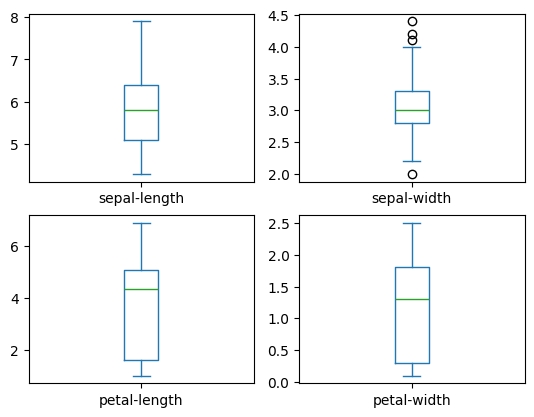

In [10]:
dataset.plot(kind='box', subplots=True, layout=(2,2), sharex=False, sharey=False)
plt.show()

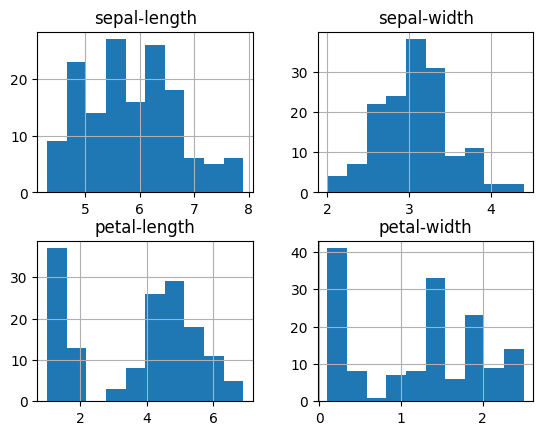

In [11]:
dataset.hist()
plt.show()

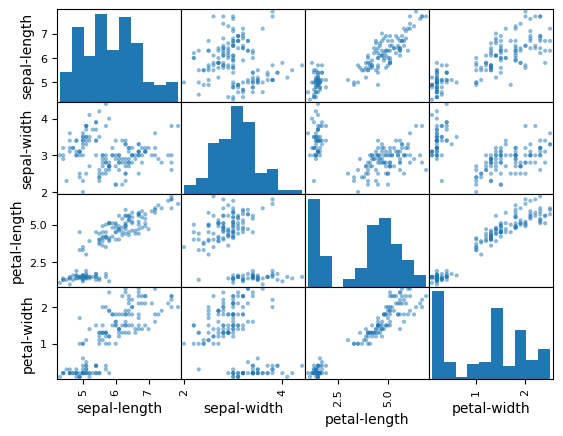

In [12]:
scatter_matrix(dataset)
plt.show()

In [13]:
array = dataset.values
X = array[:,0:4]
Y = array[:,4]
validation_size = 0.20
seed = 6
X_train, X_validation, Y_train, Y_validation = model_selection.train_test_split(X, Y, test_size=validation_size, random_state=seed)

In [14]:
seed = 6
scoring = 'accuracy'

In [16]:
# Spot Check Algorithms
models = []
models.append(('LR', LogisticRegression()))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC()))
# evaluate each model in turn
results = []
names = []

for name, model in models:
    # enable shuffling if you want to set random_state for reproducible folds
    kfold = model_selection.KFold(n_splits=10, shuffle=True, random_state=seed)
    cv_results = model_selection.cross_val_score(model, X_train, Y_train, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

LR: 0.958333 (0.041667)
LDA: 0.975000 (0.038188)
KNN: 0.958333 (0.041667)
CART: 0.941667 (0.053359)
NB: 0.966667 (0.040825)
SVM: 0.941667 (0.053359)


Epoch 0: loss=516.6887, m=1.2071, b=-0.0128
Epoch 100: loss=1.4846, m=2.2568, b=1.2109
Epoch 200: loss=1.0624, m=2.1615, b=1.8445
Epoch 300: loss=0.9064, m=2.1036, b=2.2298
Epoch 400: loss=0.8487, m=2.0684, b=2.4640
Epoch 500: loss=0.8274, m=2.0470, b=2.6064
Epoch 600: loss=0.8195, m=2.0340, b=2.6929
Epoch 700: loss=0.8166, m=2.0261, b=2.7456
Epoch 800: loss=0.8155, m=2.0213, b=2.7776
Epoch 900: loss=0.8151, m=2.0183, b=2.7970

Final model: y = 2.02x + 2.81


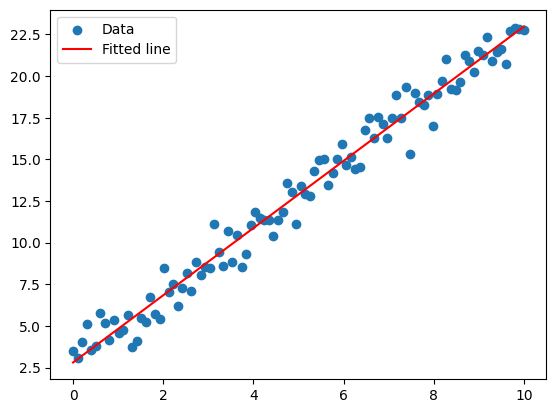

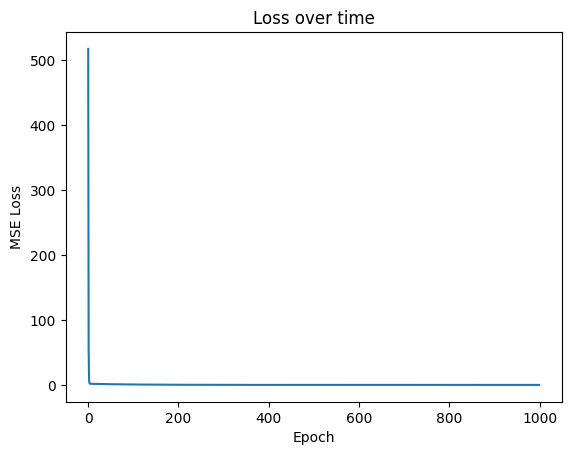

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic data (y = 2x + 3 + noise)
np.random.seed(42)
X = np.linspace(0, 10, 100)
y = 2 * X + 3 + np.random.randn(100)

# Initialize parameters
m = np.random.randn()  # slope
b = np.random.randn()  # intercept

# Hyperparameters
learning_rate = 0.01
epochs = 1000

# Store loss for visualization
loss_history = []

# Gradient descent loop
for epoch in range(epochs):
    # Predictions
    y_pred = m * X + b

    # Compute loss (Mean Squared Error)
    loss = np.mean((y - y_pred) ** 2)
    loss_history.append(loss)

    # Compute gradients
    dm = -2 * np.mean(X * (y - y_pred))
    db = -2 * np.mean(y - y_pred)

    # Update parameters
    m -= learning_rate * dm
    b -= learning_rate * db

    # Print progress every 100 steps
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: loss={loss:.4f}, m={m:.4f}, b={b:.4f}")

# Final parameters
print(f"\nFinal model: y = {m:.2f}x + {b:.2f}")

# Plot results
plt.scatter(X, y, label="Data")
plt.plot(X, m * X + b, color="red", label="Fitted line")
plt.legend()
plt.show()

# Plot loss curve
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Loss over time")
plt.show()


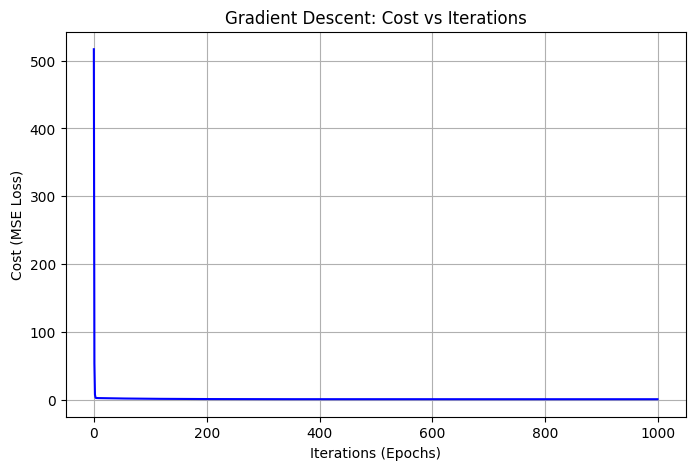

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic data
np.random.seed(42)
X = np.linspace(0, 10, 100)
y = 2 * X + 3 + np.random.randn(100)

# Initialize parameters
m = np.random.randn()
b = np.random.randn()

# Hyperparameters
learning_rate = 0.01
epochs = 1000

# Store loss history
loss_history = []

# Gradient descent loop
for epoch in range(epochs):
    # Predictions
    y_pred = m * X + b
    
    # Compute Mean Squared Error
    loss = np.mean((y - y_pred)**2)
    loss_history.append(loss)
    
    # Compute gradients
    dm = -2 * np.mean(X * (y - y_pred))
    db = -2 * np.mean(y - y_pred)
    
    # Update parameters
    m -= learning_rate * dm
    b -= learning_rate * db

# Plot Cost vs Iterations
plt.figure(figsize=(8,5))
plt.plot(range(epochs), loss_history, color='blue')
plt.xlabel("Iterations (Epochs)")
plt.ylabel("Cost (MSE Loss)")
plt.title("Gradient Descent: Cost vs Iterations")
plt.grid(True)
plt.show()


Slope: 2.0099999999999993
Intercept: 0.06999999999999958


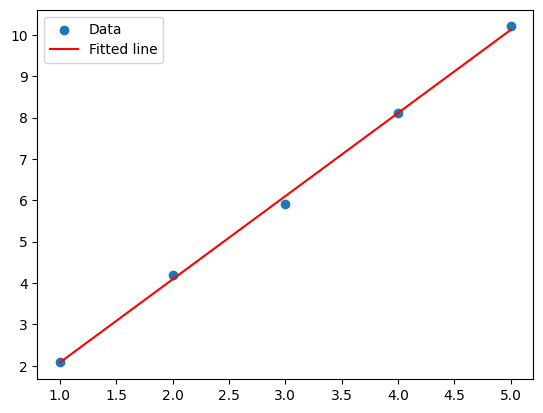

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Example data
x = np.array([1, 2, 3, 4, 5])
y = np.array([2.1, 4.2, 5.9, 8.1, 10.2])

# Create the design matrix (for y = mx + b)
A = np.vstack([x, np.ones(len(x))]).T

# Solve for the coefficients using least squares
m, b = np.linalg.lstsq(A, y, rcond=None)[0]

print(f"Slope: {m}")
print(f"Intercept: {b}")

# Plot
plt.scatter(x, y, label='Data')
plt.plot(x, m*x + b, 'r', label='Fitted line')
plt.legend()
plt.show()


Slope: 2.01
Intercept: 0.07000000000000028


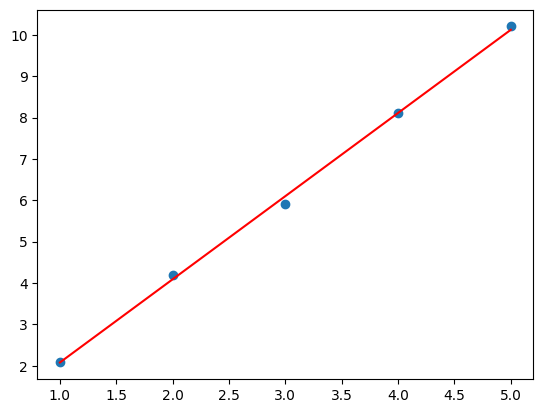

In [6]:
from sklearn.linear_model import LinearRegression

# Reshape x to 2D
x_reshaped = x.reshape(-1, 1)

# Create and train model
model = LinearRegression()
model.fit(x_reshaped, y)

# Get parameters
print(f"Slope: {model.coef_[0]}")
print(f"Intercept: {model.intercept_}")

# Predict
y_pred = model.predict(x_reshaped)

# Plot
plt.scatter(x, y)
plt.plot(x, y_pred, 'r')
plt.show()


Dataset:
   Size  Price
0   750    150
1   800    160
2   850    165
3   900    180
4   950    185
5  1000    200
6  1100    220
7  1150    230
8  1200    240
9  1300    260

Model Parameters:
Slope (Price per sq.ft): 0.20454545454545456
Intercept: -5.795454545454561

Model Evaluation:
Mean Squared Error (MSE): 2.388946280991731
R² Score: 0.9985069085743802


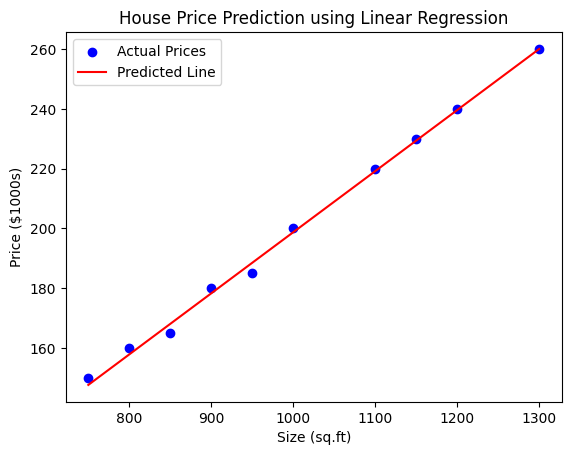

In [7]:
# -------------------------------
# House Price Prediction (Linear Regression)
# -------------------------------

# 1. Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 2. Create Example Dataset
# Dataset: House Size (sq.ft) vs Price ($1000s)
data = {
    'Size': [750, 800, 850, 900, 950, 1000, 1100, 1150, 1200, 1300],
    'Price': [150, 160, 165, 180, 185, 200, 220, 230, 240, 260]
}
df = pd.DataFrame(data)
print("Dataset:")
print(df)

# 3. Prepare Data
X = df['Size'].values.reshape(-1, 1)  # Feature (size)
y = df['Price'].values                 # Target (price)

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Train Linear Regression Model
model = LinearRegression()      # Create model
model.fit(X_train, y_train)     # Train model

# Print model parameters
print("\nModel Parameters:")
print("Slope (Price per sq.ft):", model.coef_[0])
print("Intercept:", model.intercept_)

# 5. Make Predictions
y_pred = model.predict(X_test)

# 6. Evaluate Model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("\nModel Evaluation:")
print("Mean Squared Error (MSE):", mse)
print("R² Score:", r2)

# 7. Visualize Results
plt.scatter(X, y, color='blue', label='Actual Prices')       # Actual data points
plt.plot(X, model.predict(X), color='red', label='Predicted Line')  # Regression line
plt.xlabel("Size (sq.ft)")
plt.ylabel("Price ($1000s)")
plt.title("House Price Prediction using Linear Regression")
plt.legend()
plt.show()


Dataset:
   Hours_Studied  Pass
0              1     0
1              2     0
2              3     0
3              4     0
4              5     1
5              6     1
6              7     1
7              8     1
8              9     1
9             10     1

Model trained successfully!

Predicted Classes: [1 0]
Predicted Probabilities: [0.9939848  0.06155258]

Model Evaluation:
Accuracy: 1.0
Confusion Matrix:
 [[1 0]
 [0 1]]


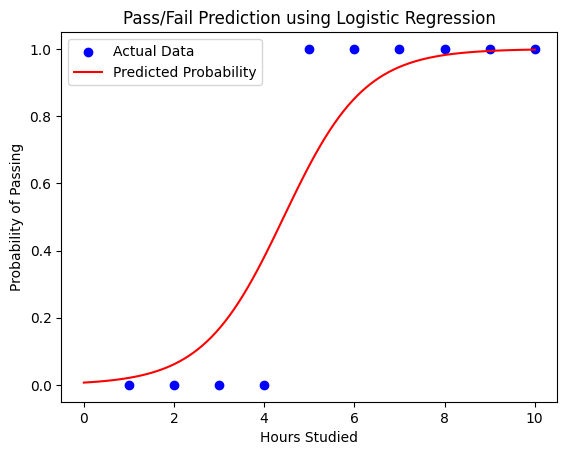

In [8]:
# -------------------------------
# Pass/Fail Prediction using Logistic Regression
# -------------------------------

# 1. Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# 2. Create Example Dataset
data = {
    'Hours_Studied': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Pass': [0, 0, 0, 0, 1, 1, 1, 1, 1, 1]
}

df = pd.DataFrame(data)
print("Dataset:")
print(df)

# 3. Prepare Data
X = df['Hours_Studied'].values.reshape(-1, 1)  # Feature matrix
y = df['Pass'].values                           # Target vector

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Train Logistic Regression Model
model = LogisticRegression()
model.fit(X_train, y_train)
print("\nModel trained successfully!")

# 5. Make Predictions
y_pred = model.predict(X_test)               # Predicted classes (0 or 1)
y_prob = model.predict_proba(X_test)[:, 1]   # Probability of passing (class 1)

print("\nPredicted Classes:", y_pred)
print("Predicted Probabilities:", y_prob)

# 6. Evaluate Model
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("\nModel Evaluation:")
print("Accuracy:", accuracy)
print("Confusion Matrix:\n", cm)

# 7. Visualize Results
plt.scatter(X, y, color='blue', label='Actual Data')
x_plot = np.linspace(0, 10, 100).reshape(-1, 1)
plt.plot(x_plot, model.predict_proba(x_plot)[:, 1], color='red', label='Predicted Probability')
plt.xlabel("Hours Studied")
plt.ylabel("Probability of Passing")
plt.title("Pass/Fail Prediction using Logistic Regression")
plt.legend()
plt.show()
